# Brain Tumor Classification

Without dataset merge (training + testing) before preprocessing. Hence,

`Acquire -> Split (Train & Test) -> Preprocess -> Split (Train & Val) -> Extract`


## Library Imports


In [1]:
import os
from glob import glob
from zipfile import ZipFile

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

import time

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Dataset Acquisition


### Import

In [2]:
data_path = "./data/"
dataset_file = data_path + "brain-sartaj.zip"

zip = ZipFile(dataset_file)
zip.extractall(data_path)
zip.close()

print(os.listdir(data_path))

['Training', 'Testing', 'brain-sartaj.zip']


### Train Test Split

In [3]:
train_path = os.path.join(data_path, "Training")
test_path = os.path.join(data_path, "Testing")

classes = os.listdir(train_path)

print("Classes:", classes)

Classes: ['meningioma_tumor', 'glioma_tumor', 'pituitary_tumor', 'no_tumor']


## Preprocessing

In [ ]:
def preprocess(datapath, label, X, y, idx):
    images = glob(os.path.join(datapath, label, "*.jpg"))

    for img in images:
        img_raw = cv.imread(img)

        # Preprocess: Image Resizing
        img_resized = cv.resize(img_raw, (64, 64))

        # Preprocess: Image Grayscaling
        img_grayscaled = cv.cvtColor(img_resized, cv.COLOR_BGR2GRAY)

        # # Preprocess: Image Normalizing
        # img_normalized = img_grayscaled / 255

        # X.append(img_normalized)
        X.append(img_grayscaled)
        y.append(idx)

In [5]:
X, y = [], []
X_test, y_test = [], []

for idx, label in enumerate(classes):
    preprocess(train_path, label, X, y, idx)
    preprocess(test_path, label, X_test, y_test, idx)

print("X data:", len(X))
print("y data:", len(y))
print("X_test data:", len(X_test))
print("y_test data:", len(y_test))

X data: 2870
y data: 2870
X_test data: 394
y_test data: 394


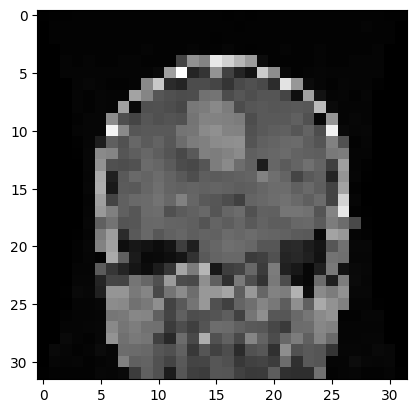

In [6]:
plt.imshow(X[0], cmap="gray")

### Data Splitting


In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42)

print("X_train data:", len(X_train))
print("y_train data:", len(y_train))
print("X_val data:", len(X_val))
print("y_val data:", len(y_val))

X_train data: 2296
y_train data: 2296
X_val data: 574
y_val data: 574


In [8]:
# Store raw preprocessed image data
# without manual feature extraction process 
# for CNN classifier

X_train_cnn = X_train.copy()
y_train_cnn = y_train.copy()
X_val_cnn = X_val.copy()
y_val_cnn = y_val.copy()

print("X_train_cnn data:", len(X_train_cnn))
print("y_train_cnn data:", len(y_train_cnn))
print("X_val_cnn data:", len(X_val_cnn))
print("y_val_cnn data:", len(y_val_cnn))

X_train_cnn data: 2296
y_train_cnn data: 2296
X_val_cnn data: 574
y_val_cnn data: 574


## Feature Extraction

### Utility Functions

In [9]:
# Convert binary to decimal pixel representation
def get_dec_from_bin(bin):
    dec = 0

    # Assign each binary digit to its decimal weight
    for bin_idx in range(len(bin)):
        power = len(bin) - bin_idx - 1
        dec += bin[bin_idx] * 2**power

    return dec

# LBP uniform pattern filtering
def is_uniform(bin):
    transition = 0

    # Compare a digit with its next digit
    # Add transition count if a value change detected
    for i in range(len(bin)-1):
        transition += 1 if bin[i] != bin[i+1] else 0
    
    # A binary pattern is uniform if the transition count is less than 3
    return True if transition < 3 else False

# Get histogram representation of uniform binary patterns from an image
def get_histogram(img):
    hist, _ = np.histogram(a=img, bins=[x for x in range(256)])

    return hist

# Visualize plotted histogram
def plot_histogram(hist):
    plt.bar(np.arange(len(hist)), hist)
    plt.show()

### Local Binary Pattern (Classic)

In [10]:
def get_lbp(img):
    height, width = img.shape
    img_lbp = np.zeros((height, width), np.uint8)

    for i in range(height):
        for j in range(width):
            c = img[i, j]

            # Neighboring pixels' coordinates from the center
            p_coords = [(i-1, j-1), (i-1, j), (i-1, j+1), # top (pixel positions from the center)
                        (i, j+1),                         # right
                        (i+1, j+1), (i+1, j), (i+1, j-1), # bottom
                        (i, j-1)]                         # left
            
            # Each center pixel's binary representation from classic LBP
            c_lbp_bin = []

            for p_coord in p_coords:
                # Handle overflowed neighboring pixels outside the image
                try:
                    # Find the intensity value of the neighboring pixels
                    # Assign 0 for negative pixel indices (above & left of the image)
                    p = img[p_coord[0], p_coord[1]] if(p_coord[0] >= 0 and p_coord[1] >= 0) else 0
                except:
                    # Out of range pixel indices (below & right of the image)
                    p = 0

                # Threshold and append binary value to pixel representation
                p_lbp_bin_dig = 1 if(p > c) else 0
                c_lbp_bin.append(p_lbp_bin_dig)

            # Assign uniform pattern pixels' decimal representation value to feature vector
            if(is_uniform(c_lbp_bin)): img_lbp[i][j] = get_dec_from_bin(c_lbp_bin)

    hist_lbp = get_histogram(img_lbp)

    return hist_lbp

### nLBP


In [11]:
def get_nlbp(img, distance):
    height, width = img.shape
    img_nlbp = np.zeros((height, width), np.uint8)
    
    for i in range(height):
        for j in range(width):
            # Neighboring pixels' coordinates from the center
            p_coords = [(i-1, j-1), (i-1, j), (i-1, j+1), # top (pixel positions from the center)
                        (  i, j+1),                       # right
                        (i+1, j+1), (i+1, j), (i+1, j-1), # bottom
                        (  i, j-1)]                       # left
            
            # Each center pixel's binary representation from nLBP
            c_nlbp_bin = []

            for p_coord_idx in range(len(p_coords)):
                # Coordinates of the two neighboring pixels based on the chosen d parameter
                p_a_idx = p_coord_idx
                p_b_idx = (p_coord_idx + distance) % 8

                # Handle overflowed neighboring pixels outside the image
                try:
                    # Find the intensity value of the neighboring pixels
                    # Assign 0 for outer edge of the first neighboring pixel (above & left)
                    p_a_bin_dig = 0 if(-1 in p_coords[p_a_idx]) else img[p_coords[p_a_idx]]
                except:
                    # Out of range pixel indices (below & right)
                    p_a_bin_dig = 0
                
                try:
                    # Find the intensity value of the neighboring pixels
                    # Assign 0 for outer edge of the second neighboring pixel (above & left)
                    p_b_bin_dig = 0 if(-1 in p_coords[p_b_idx]) else img[p_coords[p_b_idx]]
                except:
                    # Out of range pixel indices (below & right)
                    p_b_bin_dig = 0

                # Threshold and append binary value to pixel representation
                p_nlbp_bin_val = 1 if(p_a_bin_dig > p_b_bin_dig) else 0
                c_nlbp_bin.append(p_nlbp_bin_val)

            # Assign uniform pattern pixels' decimal representation value to feature vector
            if(is_uniform(c_nlbp_bin)): img_nlbp[i][j] = get_dec_from_bin(c_nlbp_bin)

    hist_nlbp = get_histogram(img_nlbp)

    return hist_nlbp

### αLBP


In [12]:
def get_albp(img, alpha):
    height, width = img.shape
    img_albp = np.zeros((height, width), np.uint8)

    # Neighboring pixel's coordinate candidates 
    # based on the chosen alpha parameter
    p_coords_list = {
        0  : [( 0, 4), ( 0, 3), ( 0, 2), ( 0, 1), ( 0,-1), ( 0,-2), ( 0,-3), ( 0,-4)],
        45 : [(-4, 4), (-3, 3), (-2, 2), (-1, 1), ( 1,-1), ( 2,-2), ( 3,-3), ( 4,-4)],
        90 : [( 4, 0), ( 3, 0), ( 2, 0), ( 1, 0), (-1, 0), (-2, 0), (-3, 0), (-4, 0)],
        135: [(-4,-4), (-3,-3), (-2,-2), (-1,-1), ( 1, 1), ( 2, 2), ( 3, 3), ( 4, 4)],
    }

    for i in range(height):
        for j in range(width):
            c = img[i][j] 
            
            # Handle alpha parameter input outside scope
            if(alpha % 360 not in p_coords_list):
                return print("Incorrect alpha parameter value")
            
            # Chosen neighboring pixels based on the alpha parameter
            p_coords = p_coords_list[alpha]

            # Each pixel's binary representation from αLBP
            c_albp_bin = []

            for p in p_coords:
                # Handle overflowed neighboring pixels outside the image
                try:
                    # Coordinates of the neighboring pixels based on their center
                    i_crd = i + p[0]
                    j_crd = j + p[1]

                    # Find neighboring pixel of a center pixel
                    # Assign 0 for negative pixel indices (above & left of the image)
                    p = img[i_crd, j_crd] if (i_crd >= 0 and j_crd >= 0) else 0 
                except:
                    # Out of range pixel indices (below & right)
                    p = 0

                # Threshold and append binary value to pixel representation
                p_albp_bin_dig = 1 if p > c else 0
                c_albp_bin.append(p_albp_bin_dig)

            # Assign each pixels' decimal representation value to feature vector
            if(is_uniform(c_albp_bin)): img_albp[i, j] = get_dec_from_bin(c_albp_bin)
    
    hist_lbp = get_histogram(img_albp)

    return hist_lbp

### TODO: MB-LBP

In [13]:
def get_integral_image(img, height, width):
    img_integral = np.zeros((height, width), int)

    for i in range(height):
        for j in range(width):
            img_integral[i,j] = img[0:i+1,0:j+1].sum()

    return img_integral

def get_semblbp(img):

    return

def get_mblbp(img, region_size):
    height, width = img.shape
    region_height = -(-height // region_size)
    region_width = -(-width // region_size)

    img_integral = get_integral_image(img, height, width)
    img_region = np.zeros((region_height, region_width), int)
    img_mblbp = np.zeros((region_height, region_width), int)

    for i in range(region_height):
        for j in range(region_width):
            try:
                a = img_integral[i*region_size-1, j*region_size-1] if(i*region_size-1>0 and j*region_size-1>0) else 0
                b = img_integral[i*region_size-1, j*region_size+region_size-1] if(i*region_size-1>0 and j*region_size+region_size-1>0) else 0
                c = img_integral[i*region_size+region_size-1, j*region_size-1] if(i*region_size+region_size-1>0 and j*region_size-1>0) else 0
                d = img_integral[i*region_size+region_size-1, j*region_size+region_size-1]

                region_mean = d - b - c + a
                img_region[i,j] = region_mean / (region_size*region_size)

            except:
                pass

    img_mblbp = get_lbp(img_region)

    return img_mblbp

for x, i in enumerate(get_albp(np.array(X_train[0]),90)):
    print(x, i)

0 406
1 24
2 15
3 15
4 12
5 0
6 5
7 21
8 21
9 0
10 0
11 0
12 14
13 0
14 8
15 95
16 17
17 0
18 0
19 0
20 0
21 0
22 0
23 0
24 3
25 0
26 0
27 0
28 3
29 0
30 5
31 20
32 12
33 0
34 0
35 0
36 0
37 0
38 0
39 0
40 0
41 0
42 0
43 0
44 0
45 0
46 0
47 0
48 6
49 0
50 0
51 0
52 0
53 0
54 0
55 0
56 3
57 0
58 0
59 0
60 1
61 0
62 0
63 7
64 12
65 0
66 0
67 0
68 0
69 0
70 0
71 0
72 0
73 0
74 0
75 0
76 0
77 0
78 0
79 0
80 0
81 0
82 0
83 0
84 0
85 0
86 0
87 0
88 0
89 0
90 0
91 0
92 0
93 0
94 0
95 0
96 5
97 0
98 0
99 0
100 0
101 0
102 0
103 0
104 0
105 0
106 0
107 0
108 0
109 0
110 0
111 0
112 3
113 0
114 0
115 0
116 0
117 0
118 0
119 0
120 5
121 0
122 0
123 0
124 3
125 0
126 5
127 12
128 16
129 4
130 0
131 0
132 0
133 0
134 0
135 0
136 0
137 0
138 0
139 0
140 0
141 0
142 0
143 5
144 0
145 0
146 0
147 0
148 0
149 0
150 0
151 0
152 0
153 0
154 0
155 0
156 0
157 0
158 0
159 2
160 0
161 0
162 0
163 0
164 0
165 0
166 0
167 0
168 0
169 0
170 0
171 0
172 0
173 0
174 0
175 0
176 0
177 0
178 0
179 0
180 0
181 0
18

In [14]:
img_dum = [[ 0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
           [10,11,12,13,14,15,16,17,18,19],
           [20,21,22,23,24,25,26,27,28,29],
           [30,31,32,33,34,35,36,37,38,39],
           [40,41,42,43,44,45,46,47,48,49],
           [50,51,52,53,54,55,56,57,58,59],
           [60,61,62,63,64,65,66,67,68,69],
           [70,71,72,73,74,75,76,77,78,79],
           [80,81,82,83,84,85,86,87,88,89],
           [90,91,92,93,94,95,96,97,98,99]]

# dum_lbp = get_lbp(np.array(X_train[0]))
# dum_nlbp = get_nlbp(np.array(X_train[0]), 2)
# dum_albp = get_albp(np.array(X_train[0]), 90)
# dum_mblbp = get_mblbp(np.array(X_train[0]), 3)
# plot_histogram(dum_lbp)
# plot_histogram(dum_nlbp)
# plot_histogram(dum_albp)
# plot_histogram(dum_mblbp)

### Execute Feature Extraction

In [15]:
# Define feature extracted data for training input
X_train_lbp, X_val_lbp = [], []
X_train_nlbp, X_val_nlbp = [], []
X_train_albp, X_val_albp = [], []

# Extract X_train images
for i, x in enumerate(X_train):
    X_train_lbp.append(get_lbp(x).flatten())
    X_train_nlbp.append(get_nlbp(x,1).flatten())
    X_train_albp.append(get_albp(x,0).flatten())
    print(f"{i}/{len(X_train)} X_train images extracted")

# Extract X_val images
for i, x in enumerate(X_val):
    X_val_lbp.append(get_lbp(x).flatten())
    X_val_nlbp.append(get_nlbp(x,1).flatten())
    X_val_albp.append(get_albp(x,0).flatten())
    print(f"{i}/{len(X_val)} X_val images extracted")

print("Image sample before feature extraction")
print(X_train[10])

print("Extracted image feature samples")
print(X_train_lbp[10])
print(X_train_nlbp[10])
print(X_train_albp[10])

0/2296 X_train images extracted
1/2296 X_train images extracted
2/2296 X_train images extracted
3/2296 X_train images extracted
4/2296 X_train images extracted
5/2296 X_train images extracted
6/2296 X_train images extracted
7/2296 X_train images extracted
8/2296 X_train images extracted
9/2296 X_train images extracted
10/2296 X_train images extracted
11/2296 X_train images extracted
12/2296 X_train images extracted
13/2296 X_train images extracted
14/2296 X_train images extracted
15/2296 X_train images extracted
16/2296 X_train images extracted
17/2296 X_train images extracted
18/2296 X_train images extracted
19/2296 X_train images extracted
20/2296 X_train images extracted
21/2296 X_train images extracted
22/2296 X_train images extracted
23/2296 X_train images extracted
24/2296 X_train images extracted
25/2296 X_train images extracted
26/2296 X_train images extracted
27/2296 X_train images extracted
28/2296 X_train images extracted
29/2296 X_train images extracted
30/2296 X_train imag

## Classification

### Evaluation Functions

In [16]:
def evaluate_model(model_name, y_val, model_preds, model_time):

    # Confusion matrix of trained model
    cm = confusion_matrix(y_val, model_preds)
    cm_disp = ConfusionMatrixDisplay(cm, display_labels=[c.removesuffix("_tumor") for c in classes])
    cm_disp.plot(cmap='cividis')
    plt.show()

    # Global performance measures
    tp, tn, fp, fn = 0, 0, 0, 0
    acc, prec, rec, f1 = 0, 0, 0, 0 
    local_perf = []

    # Evaluation matrices of trained model
    # Model predictions and performance for each classes and global-scoped
    for c in range(len(classes)):
        # Model predidctions for each class
        tp_c = cm[c,c]
        tp += tp_c
        
        tn_c = cm.sum() - cm[c,:].sum() - cm[:,c].sum() + cm[c,c]
        tn += tn_c

        fp_c = cm[:,c].sum() - cm[c,c]
        fp += fp_c

        fn_c = cm[c,:].sum() - cm[c,c]
        fn += fn_c

        # Model performance
        acc_c = (tp_c + tn_c) / (tp_c + tn_c + fp_c + fn_c)
        acc += acc_c / 4

        prec_c = tp_c / (tp_c + fp_c)
        prec += prec_c / 4

        rec_c = tp_c / (tp_c + fn_c)
        rec += rec_c / 4

        f1_c = 2 * ((prec_c * rec_c) / (prec_c + rec_c))
        f1 += f1_c / 4

        # Assign model performance of each class
        local_perf.append({
            "accuracy": acc_c,
            "precision": prec_c,
            "recall": rec_c,
            "f1-score": f1_c
        })

    acc_macro = (tp / cm.sum())

    # Assign model performance in global-scoped
    global_perf = { 
        "accuracy": acc, 
        "accuracy_macro": acc_macro, 
        "precision": prec,
        "recall": rec,
        "f1-score": f1
    }

    # Display model performance evaluation results
    display_evaluation(model_name, local_perf, global_perf, model_time)

    return local_perf, global_perf

def display_evaluation(model_name, local_perf, global_perf, model_time):
    print(f"Model & Params: {model_name}")
    print(f"Training Time : {model_time} seconds")

    for i, lp in enumerate(local_perf):
        print(f"\nLocal Performance for Class \"{classes[i]}\"")
        print(f"Accuracy : {lp["accuracy"]}",
              f"Precision: {lp["precision"]}",
              f"Recall   : {lp["recall"]}",
              f"F1-Score : {lp["f1-score"]}",
              sep="\n")
        
    print(f"\nGlobal Performance")
    print(f"Accuracy : {global_perf["accuracy"]} | {global_perf["accuracy_macro"]}",
          f"Precision: {global_perf["precision"]}",
          f"Recall   : {global_perf["recall"]}",
          f"F1-Score : {global_perf["f1-score"]}",
          sep="\n")


### Classic Machine Learning

#### K-Nearest Neighbor Model

- 3 Neighbors

In [17]:
# Define K-Nearest Neighbor model with 3 neighbors
knn_classifier_3 = KNeighborsClassifier(n_neighbors=3)

# Train LBP
start = time.perf_counter()
knn_classifier_3.fit(X_train_lbp, y_train)
end = time.perf_counter()
knn_3_lbp_time = end - start
# Test LBP
knn_3_lbp_preds = knn_classifier_3.predict(X_val_lbp)

# Train nLBP
start = time.perf_counter()
knn_classifier_3.fit(X_train_nlbp, y_train)
end = time.perf_counter()
knn_3_nlbp_time = end - start
# Test nLBP
knn_3_nlbp_preds = knn_classifier_3.predict(X_val_nlbp)

# Train aLBP
start = time.perf_counter()
knn_classifier_3.fit(X_train_albp, y_train)
end = time.perf_counter()
knn_3_albp_time = end - start
# Test aLBP
knn_3_albp_preds = knn_classifier_3.predict(X_val_albp)

- 5 Neighbors

In [18]:
# Define K-Nearest Neighbor model with 5 neighbors
knn_classifier_5 = KNeighborsClassifier(n_neighbors=5)

# Train LBP
start = time.perf_counter()
knn_classifier_5.fit(X_train_lbp, y_train)
end = time.perf_counter()
knn_5_lbp_time = end - start
# Test LBP
knn_5_lbp_preds = knn_classifier_5.predict(X_val_lbp)

# Train nLBP
start = time.perf_counter()
knn_classifier_5.fit(X_train_nlbp, y_train)
end = time.perf_counter()
knn_5_nlbp_time = end - start
# Test nLBP
knn_5_nlbp_preds = knn_classifier_5.predict(X_val_nlbp)

# Train aLBP
start = time.perf_counter()
knn_classifier_5.fit(X_train_albp, y_train)
end = time.perf_counter()
knn_5_albp_time = end - start
# Test aLBP
knn_5_albp_preds = knn_classifier_5.predict(X_val_albp)

- 7 Neighbors

In [19]:
# Define K-Nearest Neighbor model with 7 neighbors
knn_classifier_7 = KNeighborsClassifier(n_neighbors=7)

# Train LBP
start = time.perf_counter()
knn_classifier_7.fit(X_train_lbp, y_train)
end = time.perf_counter()
knn_7_lbp_time = end - start
# Test LBP
knn_7_lbp_preds = knn_classifier_7.predict(X_val_lbp)

# Train nLBP
start = time.perf_counter()
knn_classifier_7.fit(X_train_nlbp, y_train)
end = time.perf_counter()
knn_7_nlbp_time = end - start
# Test nLBP
knn_7_nlbp_preds = knn_classifier_7.predict(X_val_nlbp)

# Train aLBP
start = time.perf_counter()
knn_classifier_7.fit(X_train_albp, y_train)
end = time.perf_counter()
knn_7_albp_time = end - start
# Test aLBP
knn_7_albp_preds = knn_classifier_7.predict(X_val_albp)

#### KNN Evaluation

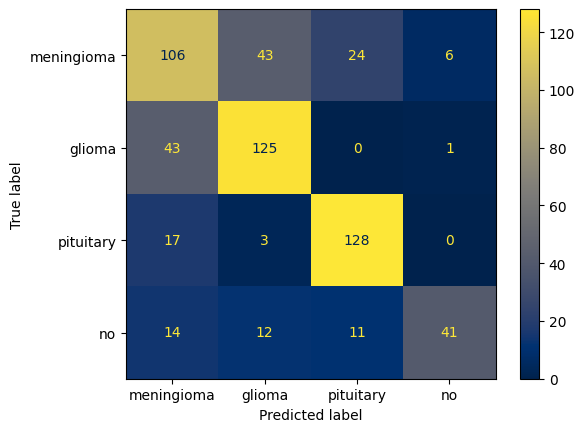

Model & Params: KNN - 3 Neighbors - LBP
Training Time : 0.0072702389999790284 seconds

Local Performance for Class "meningioma_tumor"
Accuracy : 0.7439024390243902
Precision: 0.5888888888888889
Recall   : 0.5921787709497207
F1-Score : 0.5905292479108635

Local Performance for Class "glioma_tumor"
Accuracy : 0.8222996515679443
Precision: 0.6830601092896175
Recall   : 0.7396449704142012
F1-Score : 0.7102272727272727

Local Performance for Class "pituitary_tumor"
Accuracy : 0.9041811846689896
Precision: 0.7852760736196319
Recall   : 0.8648648648648649
F1-Score : 0.8231511254019293

Local Performance for Class "no_tumor"
Accuracy : 0.9233449477351916
Precision: 0.8541666666666666
Recall   : 0.5256410256410257
F1-Score : 0.6507936507936508

Global Performance
Accuracy : 0.8484320557491289 | 0.6968641114982579
Precision: 0.7278479346162012
Recall   : 0.6805824079674531
F1-Score : 0.693675324208429


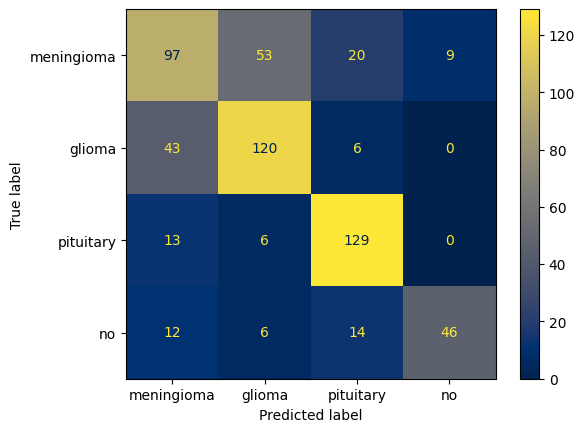

Model & Params: KNN - 3 Neighbors - nLBP
Training Time : 0.0021124870000051033 seconds

Local Performance for Class "meningioma_tumor"
Accuracy : 0.7386759581881533
Precision: 0.5878787878787879
Recall   : 0.5418994413407822
F1-Score : 0.563953488372093

Local Performance for Class "glioma_tumor"
Accuracy : 0.8013937282229965
Precision: 0.6486486486486487
Recall   : 0.7100591715976331
F1-Score : 0.6779661016949152

Local Performance for Class "pituitary_tumor"
Accuracy : 0.8972125435540069
Precision: 0.7633136094674556
Recall   : 0.8716216216216216
F1-Score : 0.8138801261829652

Local Performance for Class "no_tumor"
Accuracy : 0.9285714285714286
Precision: 0.8363636363636363
Recall   : 0.5897435897435898
F1-Score : 0.6917293233082706

Global Performance
Accuracy : 0.8414634146341464 | 0.6829268292682927
Precision: 0.7090511705896322
Recall   : 0.6783309560759067
F1-Score : 0.686882259889561


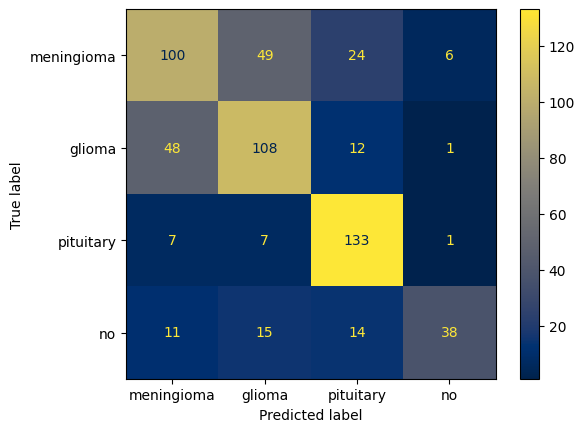

Model & Params: KNN - 3 Neighbors - aLBP
Training Time : 0.0021659450000015568 seconds

Local Performance for Class "meningioma_tumor"
Accuracy : 0.7473867595818815
Precision: 0.6024096385542169
Recall   : 0.5586592178770949
F1-Score : 0.5797101449275363

Local Performance for Class "glioma_tumor"
Accuracy : 0.7700348432055749
Precision: 0.6033519553072626
Recall   : 0.6390532544378699
F1-Score : 0.6206896551724138

Local Performance for Class "pituitary_tumor"
Accuracy : 0.8867595818815331
Precision: 0.726775956284153
Recall   : 0.8986486486486487
F1-Score : 0.8036253776435045

Local Performance for Class "no_tumor"
Accuracy : 0.9163763066202091
Precision: 0.8260869565217391
Recall   : 0.48717948717948717
F1-Score : 0.6129032258064516

Global Performance
Accuracy : 0.8301393728222997 | 0.6602787456445993
Precision: 0.689656126666843
Recall   : 0.6458851520357751
F1-Score : 0.6542321008874765


In [20]:
# Evaluate KNN 3 Neighbors model classifier
knn_3_lbp_eval = evaluate_model("KNN - 3 Neighbors - LBP", y_val, knn_3_lbp_preds, knn_3_lbp_time)
knn_3_nlbp_eval = evaluate_model("KNN - 3 Neighbors - nLBP", y_val, knn_3_nlbp_preds, knn_3_nlbp_time)
knn_3_albp_eval = evaluate_model("KNN - 3 Neighbors - aLBP", y_val, knn_3_albp_preds, knn_3_albp_time)

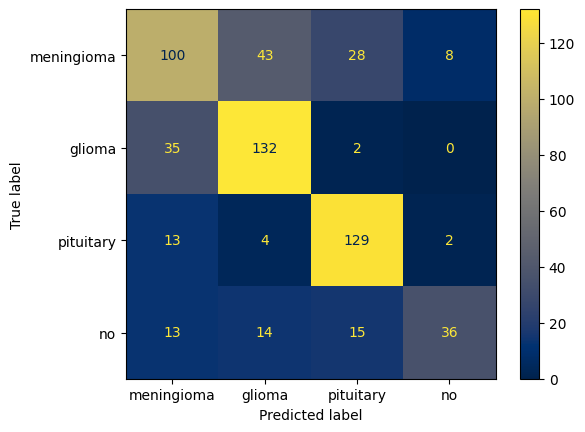

Model & Params: KNN - 5 Neighbors - LBP
Training Time : 0.006271580000003496 seconds

Local Performance for Class "meningioma_tumor"
Accuracy : 0.7560975609756098
Precision: 0.6211180124223602
Recall   : 0.5586592178770949
F1-Score : 0.588235294117647

Local Performance for Class "glioma_tumor"
Accuracy : 0.8292682926829268
Precision: 0.6839378238341969
Recall   : 0.7810650887573964
F1-Score : 0.7292817679558011

Local Performance for Class "pituitary_tumor"
Accuracy : 0.8885017421602788
Precision: 0.7413793103448276
Recall   : 0.8716216216216216
F1-Score : 0.8012422360248447

Local Performance for Class "no_tumor"
Accuracy : 0.9094076655052264
Precision: 0.782608695652174
Recall   : 0.46153846153846156
F1-Score : 0.5806451612903226

Global Performance
Accuracy : 0.8458188153310104 | 0.6916376306620209
Precision: 0.7072609605633897
Recall   : 0.6682210974486437
F1-Score : 0.6748511148471539


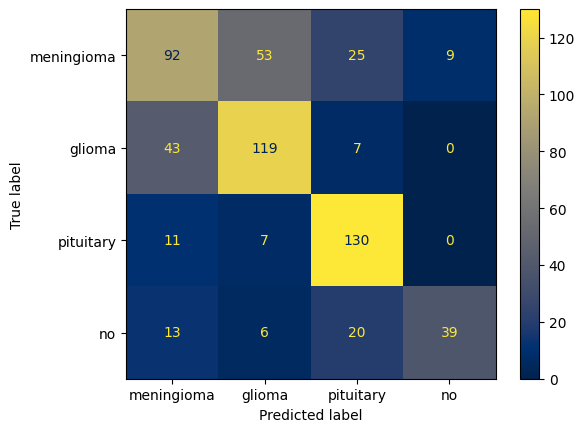

Model & Params: KNN - 5 Neighbors - nLBP
Training Time : 0.003633455999988655 seconds

Local Performance for Class "meningioma_tumor"
Accuracy : 0.7317073170731707
Precision: 0.5786163522012578
Recall   : 0.5139664804469274
F1-Score : 0.5443786982248521

Local Performance for Class "glioma_tumor"
Accuracy : 0.7979094076655052
Precision: 0.6432432432432432
Recall   : 0.7041420118343196
F1-Score : 0.672316384180791

Local Performance for Class "pituitary_tumor"
Accuracy : 0.8780487804878049
Precision: 0.7142857142857143
Recall   : 0.8783783783783784
F1-Score : 0.787878787878788

Local Performance for Class "no_tumor"
Accuracy : 0.9163763066202091
Precision: 0.8125
Recall   : 0.5
F1-Score : 0.6190476190476191

Global Performance
Accuracy : 0.8310104529616724 | 0.662020905923345
Precision: 0.6871613274325539
Recall   : 0.6491217176649063
F1-Score : 0.6559053723330125


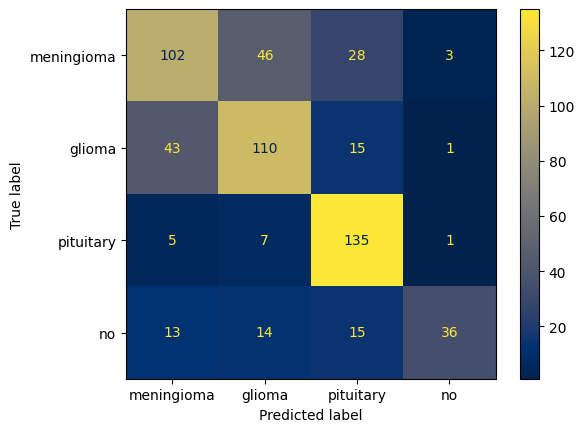

Model & Params: KNN - 5 Neighbors - aLBP
Training Time : 0.0019857730000012452 seconds

Local Performance for Class "meningioma_tumor"
Accuracy : 0.759581881533101
Precision: 0.6257668711656442
Recall   : 0.5698324022346368
F1-Score : 0.5964912280701754

Local Performance for Class "glioma_tumor"
Accuracy : 0.7804878048780488
Precision: 0.6214689265536724
Recall   : 0.650887573964497
F1-Score : 0.6358381502890174

Local Performance for Class "pituitary_tumor"
Accuracy : 0.8763066202090593
Precision: 0.6994818652849741
Recall   : 0.9121621621621622
F1-Score : 0.7917888563049854

Local Performance for Class "no_tumor"
Accuracy : 0.9181184668989547
Precision: 0.8780487804878049
Recall   : 0.46153846153846156
F1-Score : 0.6050420168067228

Global Performance
Accuracy : 0.8336236933797909 | 0.6672473867595818
Precision: 0.706191610873024
Recall   : 0.6486051499749395
F1-Score : 0.6572900628677253


In [21]:
# Evaluate KNN 5 Neighbors model classifier
knn_5_lbp_eval = evaluate_model("KNN - 5 Neighbors - LBP", y_val, knn_5_lbp_preds, knn_5_lbp_time)
knn_5_nlbp_eval = evaluate_model("KNN - 5 Neighbors - nLBP", y_val, knn_5_nlbp_preds, knn_5_nlbp_time)
knn_5_albp_eval = evaluate_model("KNN - 5 Neighbors - aLBP", y_val, knn_5_albp_preds, knn_5_albp_time)

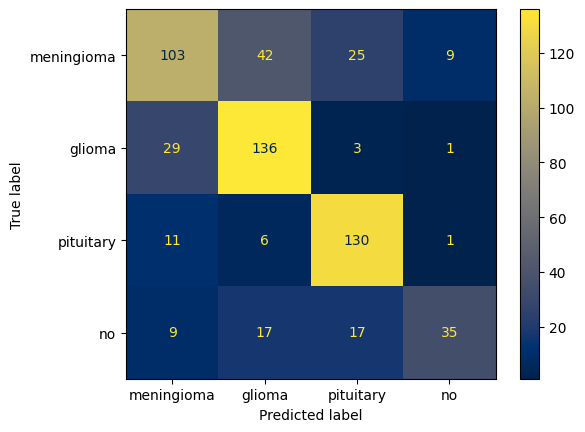

Model & Params: KNN - 7 Neighbors - LBP
Training Time : 0.012277527000009059 seconds

Local Performance for Class "meningioma_tumor"
Accuracy : 0.7822299651567944
Precision: 0.6776315789473685
Recall   : 0.5754189944134078
F1-Score : 0.6223564954682781

Local Performance for Class "glioma_tumor"
Accuracy : 0.8292682926829268
Precision: 0.6766169154228856
Recall   : 0.8047337278106509
F1-Score : 0.7351351351351351

Local Performance for Class "pituitary_tumor"
Accuracy : 0.8902439024390244
Precision: 0.7428571428571429
Recall   : 0.8783783783783784
F1-Score : 0.804953560371517

Local Performance for Class "no_tumor"
Accuracy : 0.9059233449477352
Precision: 0.7608695652173914
Recall   : 0.44871794871794873
F1-Score : 0.5645161290322581

Global Performance
Accuracy : 0.8519163763066202 | 0.7038327526132404
Precision: 0.7144938006111972
Recall   : 0.6768122623300965
F1-Score : 0.681740330001797


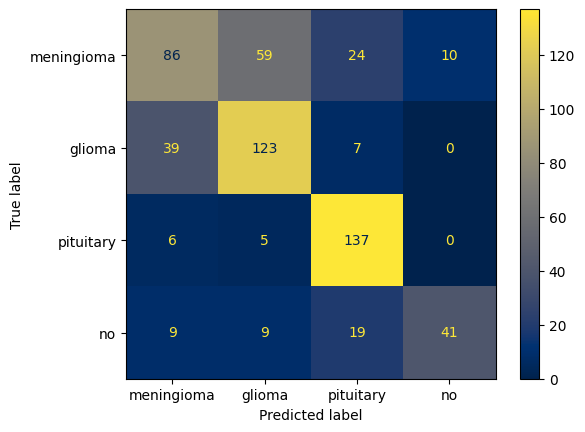

Model & Params: KNN - 7 Neighbors - nLBP
Training Time : 0.002574326999990717 seconds

Local Performance for Class "meningioma_tumor"
Accuracy : 0.7439024390243902
Precision: 0.6142857142857143
Recall   : 0.48044692737430167
F1-Score : 0.5391849529780564

Local Performance for Class "glioma_tumor"
Accuracy : 0.7926829268292683
Precision: 0.6275510204081632
Recall   : 0.727810650887574
F1-Score : 0.673972602739726

Local Performance for Class "pituitary_tumor"
Accuracy : 0.8937282229965157
Precision: 0.732620320855615
Recall   : 0.9256756756756757
F1-Score : 0.817910447761194

Local Performance for Class "no_tumor"
Accuracy : 0.9181184668989547
Precision: 0.803921568627451
Recall   : 0.5256410256410257
F1-Score : 0.6356589147286822

Global Performance
Accuracy : 0.8371080139372823 | 0.6742160278745645
Precision: 0.6945946560442359
Recall   : 0.6648935698946442
F1-Score : 0.6666817295519147


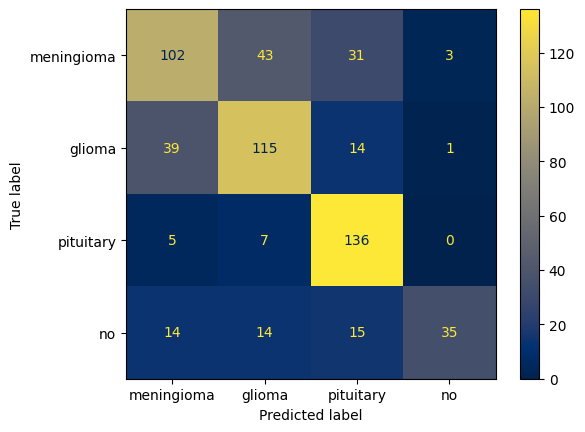

Model & Params: KNN - 7 Neighbors - aLBP
Training Time : 0.00225400200000081 seconds

Local Performance for Class "meningioma_tumor"
Accuracy : 0.764808362369338
Precision: 0.6375
Recall   : 0.5698324022346368
F1-Score : 0.6017699115044247

Local Performance for Class "glioma_tumor"
Accuracy : 0.794425087108014
Precision: 0.6424581005586593
Recall   : 0.6804733727810651
F1-Score : 0.6609195402298851

Local Performance for Class "pituitary_tumor"
Accuracy : 0.8745644599303136
Precision: 0.6938775510204082
Recall   : 0.918918918918919
F1-Score : 0.7906976744186046

Local Performance for Class "no_tumor"
Accuracy : 0.9181184668989547
Precision: 0.8974358974358975
Recall   : 0.44871794871794873
F1-Score : 0.5982905982905983

Global Performance
Accuracy : 0.8379790940766552 | 0.6759581881533101
Precision: 0.7178178872537412
Recall   : 0.6544856606631424
F1-Score : 0.6629194311108783


In [22]:
# Evaluate KNN 7 Neighbors model classifier
knn_7_lbp_eval = evaluate_model("KNN - 7 Neighbors - LBP", y_val, knn_7_lbp_preds, knn_7_lbp_time)
knn_7_nlbp_eval = evaluate_model("KNN - 7 Neighbors - nLBP", y_val, knn_7_nlbp_preds, knn_7_nlbp_time)
knn_7_albp_eval = evaluate_model("KNN - 7 Neighbors - aLBP", y_val, knn_7_albp_preds, knn_7_albp_time)

#### Decision Tree

In [23]:
# Define Decision Tree model with 3 max tree depth
dt_3_classifier = DecisionTreeClassifier(max_depth=3)

# Train LBP
start = time.perf_counter()
dt_3_classifier.fit(X_train_lbp, y_train)
end = time.perf_counter()
dt_3_lbp_time = end - start
# Test LBP
dt_3_lbp_preds = dt_3_classifier.predict(X_val_lbp)

# Train nLBP
start = time.perf_counter()
dt_3_classifier.fit(X_train_nlbp, y_train)
end = time.perf_counter()
dt_3_nlbp_time = end - start
# Test nLBP
dt_3_nlbp_preds = dt_3_classifier.predict(X_val_nlbp)

# Train aLBP
start = time.perf_counter()
dt_3_classifier.fit(X_train_albp, y_train)
end = time.perf_counter()
dt_3_albp_time = end - start
# Test aLBP
dt_3_albp_preds = dt_3_classifier.predict(X_val_albp)

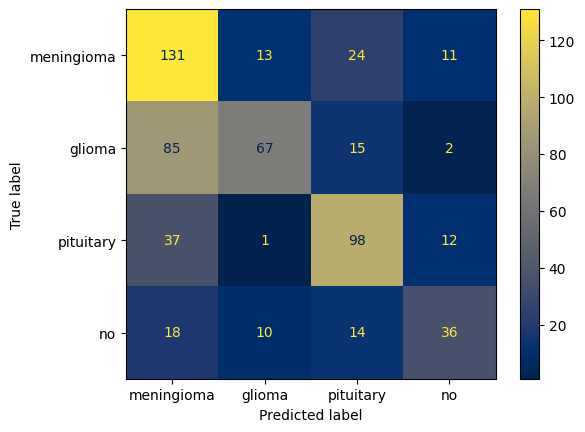

Model & Params: DT - 3 Neighbors - LBP
Training Time : 0.015423781999999164 seconds

Local Performance for Class "meningioma_tumor"
Accuracy : 0.6724738675958188
Precision: 0.4833948339483395
Recall   : 0.7318435754189944
F1-Score : 0.5822222222222222

Local Performance for Class "glioma_tumor"
Accuracy : 0.7804878048780488
Precision: 0.7362637362637363
Recall   : 0.39644970414201186
F1-Score : 0.5153846153846154

Local Performance for Class "pituitary_tumor"
Accuracy : 0.8205574912891986
Precision: 0.6490066225165563
Recall   : 0.6621621621621622
F1-Score : 0.6555183946488294

Local Performance for Class "no_tumor"
Accuracy : 0.8832752613240418
Precision: 0.5901639344262295
Recall   : 0.46153846153846156
F1-Score : 0.5179856115107915

Global Performance
Accuracy : 0.7891986062717771 | 0.578397212543554
Precision: 0.6147072817887154
Recall   : 0.5629984758154075
F1-Score : 0.5677777109416147


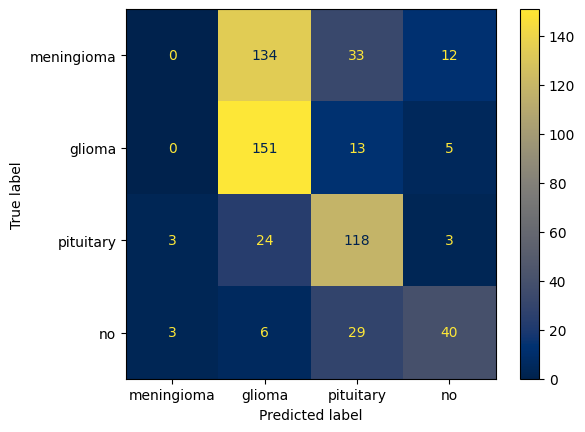

Model & Params: DT - 3 Neighbors - nLBP
Training Time : 0.008784649000006084 seconds

Local Performance for Class "meningioma_tumor"
Accuracy : 0.6777003484320557
Precision: 0.0
Recall   : 0.0
F1-Score : nan

Local Performance for Class "glioma_tumor"
Accuracy : 0.6829268292682927
Precision: 0.4793650793650794
Recall   : 0.893491124260355
F1-Score : 0.6239669421487604

Local Performance for Class "pituitary_tumor"
Accuracy : 0.8170731707317073
Precision: 0.6113989637305699
Recall   : 0.7972972972972973
F1-Score : 0.69208211143695

Local Performance for Class "no_tumor"
Accuracy : 0.8989547038327527
Precision: 0.6666666666666666
Recall   : 0.5128205128205128
F1-Score : 0.5797101449275363

Global Performance
Accuracy : 0.7691637630662022 | 0.5383275261324042
Precision: 0.43935767744057896
Recall   : 0.5509022335945413
F1-Score : nan


/tmp/ipykernel_6277/2400900387.py:40: RuntimeWarning: invalid value encountered in scalar divide
  f1_c = 2 * ((prec_c * rec_c) / (prec_c + rec_c))


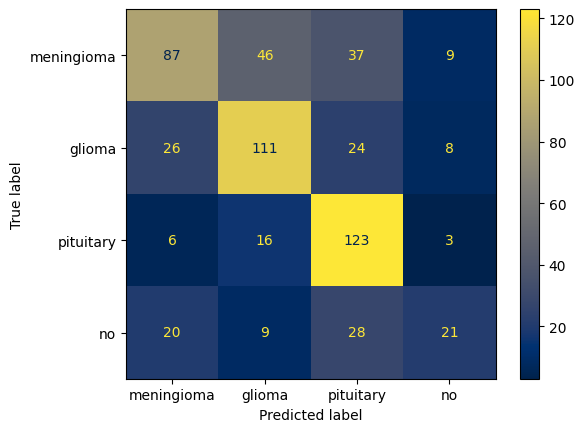

Model & Params: DT - 3 Neighbors - aLBP
Training Time : 0.010831677999988187 seconds

Local Performance for Class "meningioma_tumor"
Accuracy : 0.7491289198606271
Precision: 0.6258992805755396
Recall   : 0.4860335195530726
F1-Score : 0.5471698113207547

Local Performance for Class "glioma_tumor"
Accuracy : 0.7752613240418118
Precision: 0.6098901098901099
Recall   : 0.6568047337278107
F1-Score : 0.6324786324786326

Local Performance for Class "pituitary_tumor"
Accuracy : 0.8013937282229965
Precision: 0.5801886792452831
Recall   : 0.831081081081081
F1-Score : 0.6833333333333333

Local Performance for Class "no_tumor"
Accuracy : 0.8658536585365854
Precision: 0.5121951219512195
Recall   : 0.2692307692307692
F1-Score : 0.35294117647058826

Global Performance
Accuracy : 0.7979094076655052 | 0.5958188153310104
Precision: 0.5820432979155381
Recall   : 0.5607875258981834
F1-Score : 0.5539807384008272


In [24]:
# Evaluate Decision Tree 3 depth model classifier
dt_3_lbp_eval = evaluate_model("DT - 3 Neighbors - LBP", y_val, dt_3_lbp_preds, dt_3_lbp_time)
dt_3_nlbp_eval = evaluate_model("DT - 3 Neighbors - nLBP", y_val, dt_3_nlbp_preds, dt_3_nlbp_time)
dt_3_albp_eval = evaluate_model("DT - 3 Neighbors - aLBP", y_val, dt_3_albp_preds, dt_3_albp_time)

In [25]:
# Define Decision Tree model classifier
dt_3_classifier = DecisionTreeClassifier()

# Train Decision Tree model classifier
dt_3_classifier.fit(X_train, y_train)

# Test Decision Tree model classifier
dt_preds = dt_3_classifier.predict(X_val)

ValueError: Found array with dim 3, while dim <= 2 is required by DecisionTreeClassifier.

In [ ]:
# Evaluate Decision Tree model classifier
dt_eval = evaluate_model("Decision Tree", y_val, dt_preds)

### Random Forest

In [ ]:
# Define Random Forest model classifier
rf_classifier = RandomForestClassifier()

# Train Random Forest model classifier
rf_classifier.fit(X_train, y_train)

# Test Random Forest model classifier
rf_preds = rf_classifier.predict(X_val)

# Evaluate Random Forest model classifier
rf_eval = evaluate_model("Random Forest", y_val, rf_preds)

### Naive Bayes

In [ ]:
# Define Naive Bayes model classifier
gnb_classifier = GaussianNB()

# Train Naive Bayes model classifier
gnb_classifier.fit(X_train, y_train)

# Test Naive Bayes model classifier
gnb_preds = gnb_classifier.predict(X_val)

# Evaluate Naive Bayes model classifier
gnb_eval = evaluate_model("Gaussian Naive Bayes", y_val, gnb_preds)

In [ ]:
# Define Naive Bayes model classifier
mnb_classifier = MultinomialNB()

# Train Naive Bayes model classifier
mnb_classifier.fit(X_train, y_train)

# Test Naive Bayes model classifier
mnb_preds = mnb_classifier.predict(X_val)

# Evaluate Naive Bayes model classifier
mnb_eval = evaluate_model("Multinomial Naive Bayes", y_val, mnb_preds)

#### Support Vector Machine

In [ ]:
# classifier = SVC()
# classifier.fit(X_train, y_train)

# classifier.predict(X_test)